[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025, Petr Krysl, pkrysl@ucsd.edu

# Example of a support-settlement problem

Last updated: 07/11/26

## Problem description:

Statically indeterminate beam with two spans. The beam is supported at a pin
that settles by a given amount.

Displacements and internal forces are provided in the book, and we can check our
solution against these reference values.

## References

This example is completely solved in the book Matrix Analysis of Structures by
Robert E. Sennett, ISBN 978-1577661436 (Section 3.8).

## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)

In [1]:
import scipy
import context
from pystran import model
from pystran import section
from pystran import beam
from pystran import plots

US customary units, inches, pounds, seconds are assumed.

The book gives the product of the modulus of elasticity and the moment
of inertia as 2.9e6. The cross-sectional area does not influence the results.


In [2]:
E = 2.9e6
I = 1.0
A = 1.0  # cross-sectional area does not influence the results
L = 10 * 12  # span in inches

The model is created as two dimensional.


In [3]:
m = model.create(2)
freedoms = m["freedoms"]

In [4]:
model.add_joint(m, 1, [0.0, 0.0])
model.add_joint(m, 2, [L, 0.0])
model.add_joint(m, 3, [2 * L, 0.0])

The left hand side is clamped (all degrees of freedom set to zero), the other
joints are simply supported.


In [5]:
model.add_support(m["joints"][1], freedoms.ALL_DOFS)


The middle support moves down by 0.25 inches (notice the non zero value of the
enforced displacement).


In [6]:
model.add_support(m["joints"][2], freedoms.U2, -0.25)
model.add_support(m["joints"][3], freedoms.U2)

Define the beam members.


In [7]:
s1 = section.beam_2d_section("s1", E, A, I)
model.add_beam_member(m, 1, [1, 2], s1)
model.add_beam_member(m, 2, [2, 3], s1)

Next we display the displacements. We have to magnify the prescribed
displacement 50x, otherwise it would not be visible properly (the default
scale doesn't work well in this case).


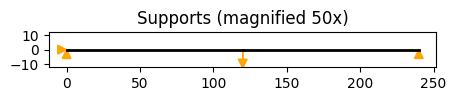

In [8]:
ax = plots.setup(m, set_limits=True)
plots.plot_members(m)
plots.plot_translation_supports(m, 50)
ax.set_title("Supports (magnified 50x)")
plots.show(m)

Solve the discrete model.


In [9]:
model.number_dofs(m)
model.solve_statics(m)

Now we print the displacements at the joints.

In [10]:
for j in m["joints"].values():
    print("Joint", j["jid"], "displacements", j["displacements"])

Joint 1 displacements [0. 0. 0.]
Joint 2 displacements [ 0.         -0.25       -0.00089286]
Joint 3 displacements [0.         0.         0.00357143]


The first sanity check is the plot of the deformation.


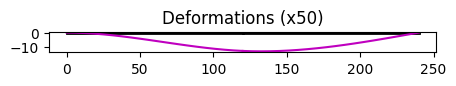

In [11]:
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_deformations(m, 50.0)
ax.set_title("Deformations (x50)")
plots.show(m)

The reference text provides the following values for the internal forces. We
check the end forces at the starting joint in member 1:


In [12]:
member = m["beam_members"][1]
connectivity = member["connectivity"]
i, j = m["joints"][connectivity[0]], m["joints"][connectivity[1]]
f = beam.beam_2d_end_forces(member, i, j)
print("Member 1 end forces: ", f)
if abs(f["Ni"]) > 1e-3:
    raise ValueError("Incorrect force")
if abs(f["Qzi"] / 3.9558 - 1) > 1e-3:
    raise ValueError("Incorrect force")
if abs(f["Myi"] / -258.92857 - 1) > 1e-3:
    raise ValueError("Incorrect force")

Member 1 end forces:  {'Ni': np.float64(0.0), 'Qzi': np.float64(3.9558531746031744), 'Myi': np.float64(-258.9285714285714), 'Nj': np.float64(-0.0), 'Qzj': np.float64(-3.9558531746031744), 'Myj': np.float64(-215.77380952380946)}


 Next, we check the end forces at the starting joint in member 2:


In [13]:
member = m["beam_members"][2]
connectivity = member["connectivity"]
i, j = m["joints"][connectivity[0]], m["joints"][connectivity[1]]
f = beam.beam_2d_end_forces(member, i, j)
print("Member 2 end forces: ", f)
if abs(f["Ni"]) > 1e-3:
    raise ValueError("Incorrect force")
if abs(f["Qzi"] / -1.7981 - 1) > 1e-3:
    raise ValueError("Incorrect force")
if abs(f["Myi"] / 215.7738 - 1) > 1e-3:
    raise ValueError("Incorrect force")

Member 2 end forces:  {'Ni': np.float64(0.0), 'Qzi': np.float64(-1.79811507936508), 'Myi': np.float64(215.77380952380955), 'Nj': np.float64(-0.0), 'Qzj': np.float64(1.79811507936508), 'Myj': np.float64(-3.9302328752599536e-14)}


Here we show the local coordinate systems, in which the internal resultants
are displayed in the next two graphs.


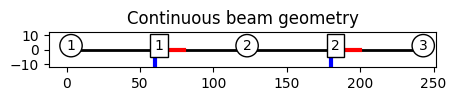

In [14]:
plots.setup(m, set_limits=True)
plots.plot_members(m)
plots.plot_member_ids(m)
plots.plot_joint_ids(m)
ax = plots.plot_member_orientation(m, 20.0)
ax.set_title("Continuous beam geometry")
plots.show(m)

The internal forces are shown in the local coordinate system of the beams.
These are the bending moments.


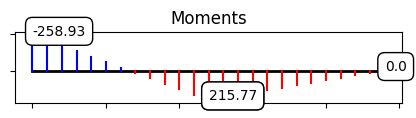

In [15]:
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_bending_moments(m)
ax.set_title("Moments")
plots.show(m)

And these are the shear forces.


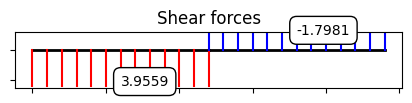

In [16]:
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_shear_forces(m)
ax.set_title("Shear forces")
plots.show(m)